In [1]:
model_checkpoint = "facebook/dinov2-base" # pre-trained model from which to fine-tune
batch_size = 32 # batch size for training and evaluation

In [ ]:
# Update the package list and install Python 3.10
! apt-get update -y
! apt-get install python3.10 python3.10-distutils -y

# Download and install 'pip' specifically for Python 3.10
! curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
! python3.10 get-pip.py

! python3.10 -m pip install ipykernel
! python3.10 -m ipykernel install --user --name=python310 --display-name "Python 3.10 (Custom)"

In [2]:
! pip install evaluate
! pip install -q datasets

: 

In [ ]:
! pip install transformers==4.33.2
! pip install accelerate==0.23.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 35.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 44.8 MB/s eta 0:00:00:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:
      Successfully uninstalled transformers-4.57.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.


In [4]:
from huggingface_hub import notebook_login

notebook_login()

In [5]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

In [6]:
import os
import pandas as pd
from datasets import Dataset, DatasetDict, Features, Image, ClassLabel
import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
image_dir = os.path.join(path, "ham10000_images_part_1")
df = pd.read_csv(os.path.join(path, "HAM10000_metadata.csv"))

# Map image IDs to  file paths
df['image'] = df['image_id'].apply(lambda x: os.path.join(image_dir, f"{x}.jpg"))

# Filter for part_1 (~5000 images)
df = df[df['image'].apply(os.path.exists)].reset_index(drop=True)

# Create Dataset with specific Features
features = Features({
    "image": Image(),
    "dx": ClassLabel(names=list(df['dx'].unique()))
})

raw_dataset = Dataset.from_pandas(df[['image', 'dx']], features=features)
cleaned_dataset = raw_dataset.rename_column("dx", "label")
dataset = DatasetDict({
    'train': cleaned_dataset
})

print(dataset)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5000
    })
})


In [7]:
import evaluate

metric = evaluate.load("accuracy")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [8]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5000
    })
})

In [9]:
dataset["train"].features

{'image': Image(mode=None, decode=True),
 'label': ClassLabel(names=['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'])}

In [10]:
example = dataset["train"][10]
example

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450>,
 'label': 0}

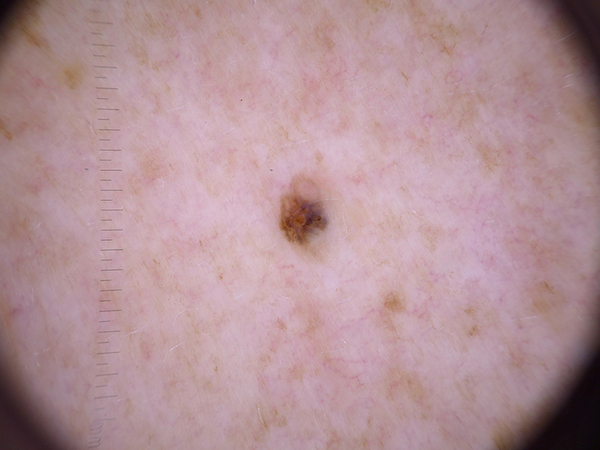

In [11]:
example['image']

In [12]:
example['label']

0

In [13]:
dataset["train"].features["label"]

ClassLabel(names=['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'])

In [14]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[2]

'df'

In [15]:
from transformers import AutoImageProcessor

image_processor  = AutoImageProcessor.from_pretrained(model_checkpoint)
image_processor

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


BitImageProcessor {
  "_valid_processor_keys": [
    "images",
    "do_resize",
    "size",
    "resample",
    "do_center_crop",
    "crop_size",
    "do_rescale",
    "rescale_factor",
    "do_normalize",
    "image_mean",
    "image_std",
    "do_convert_rgb",
    "return_tensors",
    "data_format",
    "input_data_format"
  ],
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}

In [16]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
if "height" in image_processor.size:
    size = (image_processor.size["height"], image_processor.size["width"])
    crop_size = size
    max_size = None
elif "shortest_edge" in image_processor.size:
    size = image_processor.size["shortest_edge"]
    crop_size = (size, size)
    max_size = image_processor.size.get("longest_edge")

train_transforms = Compose(
        [
            RandomResizedCrop(crop_size),
            RandomHorizontalFlip(),
            ToTensor(),
            normalize,
        ]
    )

val_transforms = Compose(
        [
            Resize(size),
            CenterCrop(crop_size),
            ToTensor(),
            normalize,
        ]
    )

def preprocess_train(example_batch):
    """Apply train_transforms across a batch."""
    example_batch["pixel_values"] = [
        train_transforms(image.convert("RGB")) for image in example_batch["image"]
    ]
    return example_batch

def preprocess_val(example_batch):
    """Apply val_transforms across a batch."""
    example_batch["pixel_values"] = [val_transforms(image.convert("RGB")) for image in example_batch["image"]]
    return example_batch

In [17]:
# split up training into training + validation
splits = dataset["train"].train_test_split(test_size=0.1)
train_ds = splits['train']
val_ds = splits['test']

In [18]:
train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

In [19]:
train_ds[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450>,
 'label': 0,
 'pixel_values': tensor([[[1.5468, 1.5125, 1.5125,  ..., 1.4440, 1.4440, 1.4098],
          [1.4954, 1.5125, 1.5297,  ..., 1.4098, 1.3927, 1.4098],
          [1.5125, 1.5125, 1.5297,  ..., 1.4098, 1.4098, 1.3755],
          ...,
          [1.4954, 1.5125, 1.3927,  ..., 1.4954, 1.4783, 1.4612],
          [1.3755, 1.3927, 1.3927,  ..., 1.5125, 1.5125, 1.5125],
          [1.3927, 1.4098, 1.3927,  ..., 1.5468, 1.5297, 1.5125]],
 
         [[0.7479, 0.7304, 0.6604,  ..., 0.6954, 0.7129, 0.7129],
          [0.7304, 0.7304, 0.6604,  ..., 0.7129, 0.6954, 0.6954],
          [0.7479, 0.7129, 0.6078,  ..., 0.7304, 0.7304, 0.6779],
          ...,
          [0.4328, 0.4328, 0.4678,  ..., 0.7654, 0.7654, 0.7654],
          [0.4328, 0.4328, 0.4853,  ..., 0.8004, 0.8004, 0.8179],
          [0.4503, 0.4503, 0.5028,  ..., 0.8179, 0.8004, 0.8004]],
 
         [[1.0714, 1.0539, 0.9494,  ..., 0.8099, 0.8274, 0.8622],
  

In [20]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes = True, # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)


RuntimeError: Failed to import transformers.trainer because of the following error (look up to see its traceback):
cannot import name 'clear_device_cache' from 'accelerate.utils.memory' (/usr/local/lib/python3.12/dist-packages/accelerate/utils/memory.py)

In [ ]:
import accelerate
import transformers

transformers.__version__, accelerate.__version__

('4.57.6', '1.12.0')

In [ ]:
model_name = model_checkpoint.split("/")[-1]

args = TrainingArguments(
    f"dinov2-base-rawdata-finetuned-SkinDisease",
    remove_unused_columns=False,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=10,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
)

In [ ]:
import numpy as np

# the compute_metrics function takes a Named Tuple as input:
# predictions, which are the logits of the model as Numpy arrays,
# and label_ids, which are the ground-truth labels as Numpy arrays.
def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [ ]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

: 

In [ ]:
train_results = trainer.train()
# rest is optional but nice to have
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: jkz5411 (jkz5411-penn-state-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


: 

: 

In [ ]:
metrics = trainer.evaluate()
# some nice to haves:
trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

In [ ]:
trainer.push_to_hub()

In [ ]:
test_ds

In [ ]:
from transformers import AutoModelForImageClassification, AutoImageProcessor
from sklearn.metrics import accuracy_score
import torch

# Load the pre-trained model and image processor
repo_name = "Jayanth2002/dinov2-base-rawdata-finetuned-SkinDisease"
image_processor = AutoImageProcessor.from_pretrained(repo_name)
model = AutoModelForImageClassification.from_pretrained(repo_name)

# Load and preprocess the test images
test_data_dir = "/kaggle/input/raw-paper/test"  # Path to the test data directory
test_images = load_dataset("imagefolder", data_dir=test_data_dir)

# Preprocess the test images
test_images.set_transform(preprocess_val)  # Use the same validation transforms

# Create a test dataset
test_ds = test_images["train"]  # Use the "train" split for the test data





In [ ]:
# Initialize lists to store predicted and actual labels
predicted_labels = []
actual_labels = []

# Iterate through the test dataset and make predictions
for example in test_ds:
    image = example["image"]
    encoding = image_processor(image.convert("RGB"), return_tensors="pt")

    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits

    predicted_class_idx = logits.argmax(-1).item()
    predicted_labels.append(predicted_class_idx)
    actual_labels.append(example["label"])

# Calculate accuracy
accuracy = accuracy_score(actual_labels, predicted_labels)

print(f"Test Accuracy: {accuracy:.4f}")